# IDSC2026 Brugada-HUCA Classification Baseline

## Objective
Build a binary classification model to distinguish Brugada syndrome from normal controls using the Brugada-HUCA dataset.

## Strategy
Pipeline steps:
1. Load metadata and ECG WFDB files
2. Visualize samples and run quality checks
3. Preprocess the signals
4. Detect R peaks and extract the median beat
5. Build full-strip and beat morphology features
6. Train an XGBoost model
7. Evaluate AUC, F1, accuracy, sensitivity, and specificity
8. Add explainability with feature importance and SHAP

## Why this approach
Because the dataset is small, a tabular approach based on ECG morphology features is:
- stable
- explainable
- suitable for small datasets
- easy to present in a short pitch


### Step 1 - Install Dependencies

Install the main packages for WFDB loading, explainability, and the baseline model.


In [1]:
!pip -q install wfdb shap xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.0 MB/s eta 0:00:00


### Step 2 - Import Libraries and Config

Prepare all imports, global constants, and plotting settings.


In [2]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from scipy.signal import butter, filtfilt, find_peaks, savgol_filter
from scipy.stats import skew, kurtosis

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, accuracy_score,
    balanced_accuracy_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

from xgboost import XGBClassifier
import shap
import wfdb

randomState = 42
fsExpected = 100
standardLeads = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

# 1. Locate the Dataset Automatically
This notebook searches for metadata.csv and all .hea files recursively inside /kaggle/input.


### Step 3 - Find Metadata and Dataset Root

Locate metadata.csv and the main dataset path automatically from Kaggle input.


In [3]:
inputRoot = "/kaggle/input"

metaCandidates = glob.glob(os.path.join(inputRoot, "**", "metadata.csv"), recursive=True)
assert len(metaCandidates) > 0, "metadata.csv not found in /kaggle/input"

metaPath = metaCandidates[0]
datasetRoot = os.path.dirname(metaPath)

print("Metadata path:", metaPath)
print("Dataset root:", datasetRoot)

metadata = pd.read_csv(metaPath)
display(metadata.head())

print("Metadata shape:", metadata.shape)
print("Columns:", metadata.columns.tolist())

Metadata path: /kaggle/input/datasets/izzarsulynashrudin/brugada-huca/metadata.csv
Dataset root: /kaggle/input/datasets/izzarsulynashrudin/brugada-huca


,patient_id,basal_pattern,sudden_death,brugada
0,188981,1,0,1
1,251972,0,0,0
2,265715,0,0,0
3,267628,0,0,0
4,267630,0,0,1


Metadata shape: (363, 4)
Columns: ['patient_id', 'basal_pattern', 'sudden_death', 'brugada']


# 2. Basic EDA
Check the target label distribution and several important metadata columns.


### Step 4 - Explore the Target Distribution

Review the Brugada versus Normal label balance and the key metadata summary.


brugada
0    287
1     69
2      7
Name: count, dtype: int64

brugada
0    0.790634
1    0.190083
2    0.019284
Name: proportion, dtype: float64


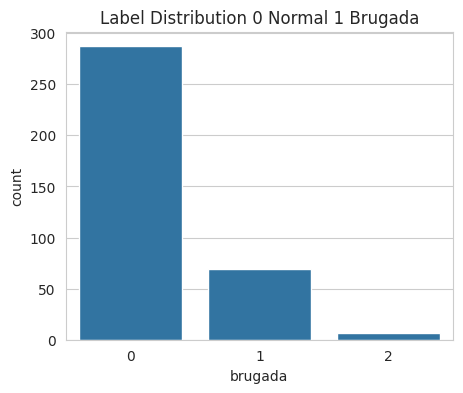

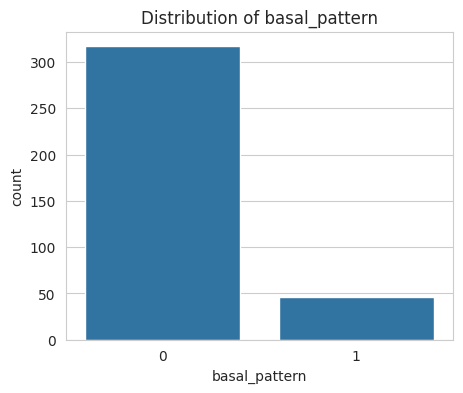

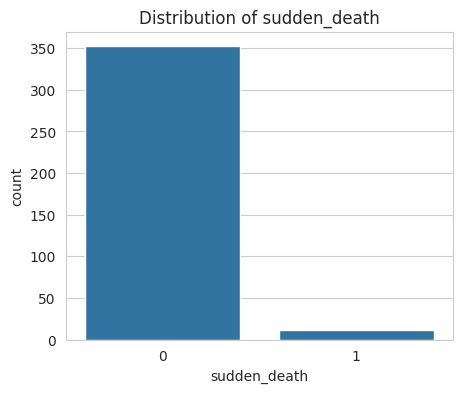

In [4]:
print(metadata["brugada"].value_counts(dropna=False))
print()
print(metadata["brugada"].value_counts(normalize=True).rename("proportion"))

plt.figure(figsize=(5,4))
sns.countplot(x=metadata["brugada"])
plt.title("Label Distribution 0 Normal 1 Brugada")
plt.show()

for columnName in ["basal_pattern", "sudden_death"]:
    if columnName in metadata.columns:
        plt.figure(figsize=(5,4))
        sns.countplot(x=metadata[columnName])
        plt.title(f"Distribution of {columnName}")
        plt.show()

### Step 5 - Index the WFDB Files

Build a mapping from patient_id to each ECG recording file.


In [5]:
heaFiles = glob.glob(os.path.join(datasetRoot, "**", "*.hea"), recursive=True)
print("Total .hea files found:", len(heaFiles))

recordMap = {}
for hea in heaFiles:
    pid = os.path.splitext(os.path.basename(hea))[0]
    recordMap[str(pid)] = os.path.splitext(hea)[0]

print("Indexed records:", len(recordMap))

missingIds = [str(pid) for pid in metadata["patient_id"].astype(str) if str(pid) not in recordMap]
print("Missing patient IDs in file index:", len(missingIds))
if len(missingIds) > 0:
    print("Example missing IDs:", missingIds[:10])

Total .hea files found: 363
Indexed records: 363
Missing patient IDs in file index: 0


### Step 6 - ECG Loading Helper

Define the helper function that loads ECG records and standardizes lead names.


In [6]:
def standardizeLeadNames(sigNames):
    mapping = {}
    for s in sigNames:
        mapping[s] = s.strip().replace("AVR", "aVR").replace("AVL", "aVL").replace("AVF", "aVF")
    return mapping

def loadEcgRecord(patientId):
    patientId = str(patientId)
    assert patientId in recordMap, f"Record for patient_id {patientId} not found"

    rec = wfdb.rdrecord(recordMap[patientId])
    sig = pd.DataFrame(rec.p_signal, columns=rec.sig_name)

    nameMapLocal = standardizeLeadNames(sig.columns.tolist())
    sig = sig.rename(columns=nameMapLocal)

    for ld in standardLeads:
        if ld not in sig.columns:
            raise ValueError(f"Lead {ld} not found for patient_id {patientId}")

    sig = sig[standardLeads].copy()
    fs = rec.fs
    return sig.values.astype(np.float32), standardLeads, fs

### Step 7 - Visualize ECG Samples

Plot one Normal sample and one Brugada sample for an initial sanity check.


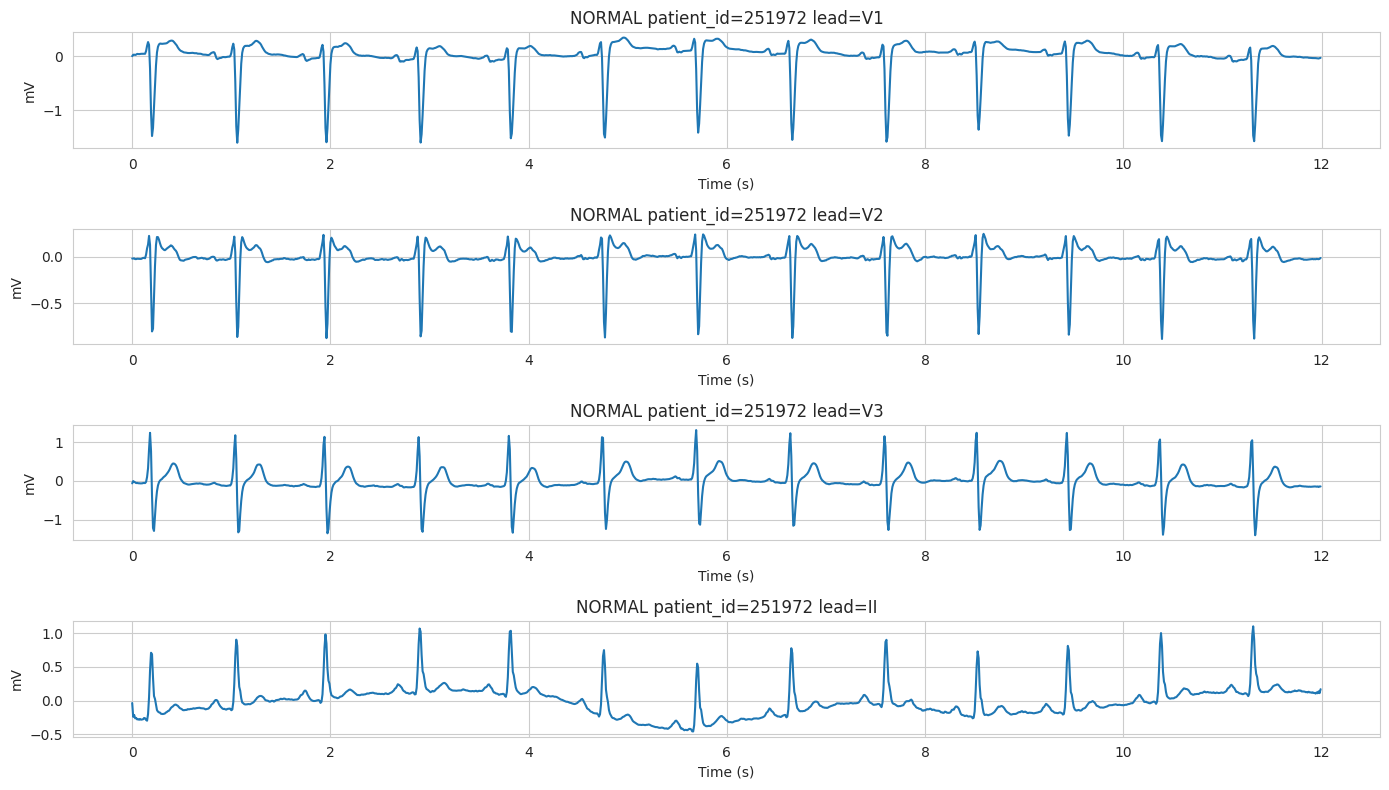

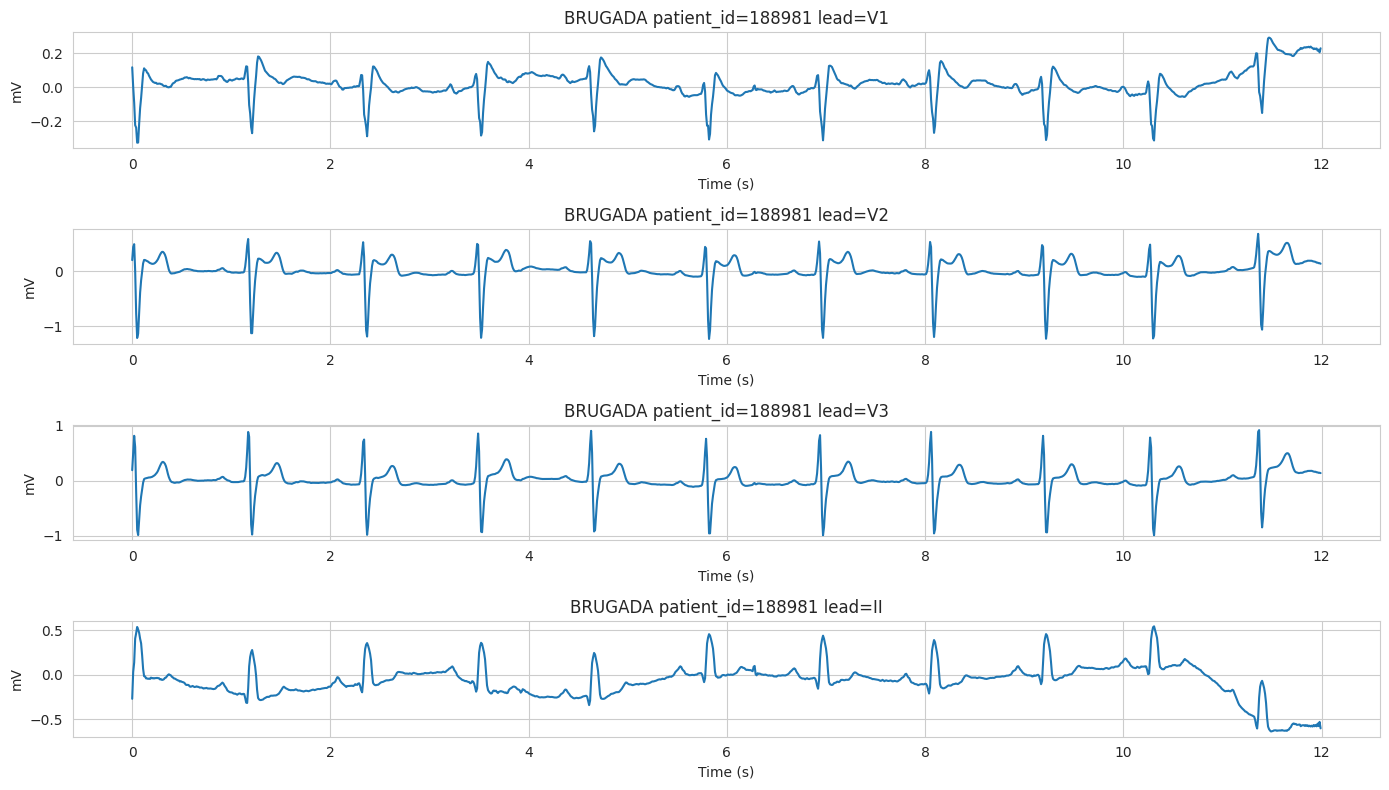

In [7]:
normalId = metadata.loc[metadata["brugada"] == 0, "patient_id"].iloc[0]
brugadaId = metadata.loc[metadata["brugada"] == 1, "patient_id"].iloc[0]

def plotSelectedLeads(patientId, leadsToPlot=("V1", "V2", "V3", "II"), titlePrefix=""):
    X, leads, fs = loadEcgRecord(patientId)
    t = np.arange(len(X)) / fs

    plt.figure(figsize=(14, 8))
    for i, ld in enumerate(leadsToPlot, 1):
        idx = leads.index(ld)
        plt.subplot(len(leadsToPlot), 1, i)
        plt.plot(t, X[:, idx])
        plt.title(f"{titlePrefix} patient_id={patientId} lead={ld}")
        plt.xlabel("Time (s)")
        plt.ylabel("mV")
    plt.tight_layout()
    plt.show()

plotSelectedLeads(normalId, titlePrefix="NORMAL")
plotSelectedLeads(brugadaId, titlePrefix="BRUGADA")

# 3. Preprocessing and Beat Extraction

Because the dataset release does not provide extra preprocessing, we will:
1. apply a 0.5 to 40 Hz bandpass filter
2. apply robust normalization per lead
3. detect R peaks
4. extract a median beat

The goal is to keep the model focused on the most relevant morphology patterns.


### Step 8 - Signal Preprocessing

Define bandpass filtering, robust scaling, R peak detection, and median beat extraction.


In [8]:
def bandpassFilter(x, fs, low=0.5, high=40.0, order=3):
    nyq = 0.5 * fs
    low = max(low / nyq, 1e-4)
    high = min(high / nyq, 0.99)
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, x, axis=0)

def robustScale(x):
    med = np.median(x, axis=0, keepdims=True)
    mad = np.median(np.abs(x - med), axis=0, keepdims=True)
    mad = np.where(mad < 1e-6, 1.0, mad)
    return (x - med) / (1.4826 * mad)

def detectRPeaks(signal1d, fs):
    x = signal1d.copy()
    if len(x) >= 11:
        x = savgol_filter(x, 11, 3)
    x = x - np.median(x)

    prominence = max(0.15, np.std(x) * 0.5)
    distance = int(0.45 * fs)

    peaks, _ = find_peaks(x, distance=distance, prominence=prominence)

    if len(peaks) == 0:
        peaks, _ = find_peaks(np.abs(x), distance=distance, prominence=np.std(np.abs(x)) * 0.3)
    return peaks

def extractMedianBeat(X, leads, fs):
    leadPriority = ["II", "V2", "V1", "V3", "I"]
    pre = int(0.25 * fs)
    post = int(0.45 * fs)

    peaks = np.array([])
    for refLead in leadPriority:
        if refLead in leads:
            refIndex = leads.index(refLead)
            peaks = detectRPeaks(X[:, refIndex], fs)
            peaks = peaks[(peaks > pre) & (peaks < len(X) - post)]
            if len(peaks) >= 2:
                break

    beats = []
    for p in peaks:
        beat = X[p-pre:p+post, :]
        if beat.shape[0] == pre + post:
            beats.append(beat)

    if len(beats) == 0:
        center = len(X) // 2
        beat = X[max(0, center-pre):min(len(X), center+post), :]
        pad = np.zeros((pre + post, X.shape[1]), dtype=np.float32)
        pad[:beat.shape[0], :] = beat
        return pad, pre

    median_beat = np.median(np.stack(beats, axis=0), axis=0)
    return median_beat, pre

### Step 9 - ECG Feature Engineering

Extract strip statistics, beat morphology features, and clinically focused cross lead features.


In [9]:
def zeroCrossings(x):
    return np.sum(np.diff(np.signbit(x)).astype(int))

def safeSlope(y):
    if len(y) < 2:
        return 0.0
    xs = np.arange(len(y))
    return float(np.polyfit(xs, y, 1)[0])

def extractStripFeatures(x, prefix):
    featureMap = {
        f"{prefix}_mean": float(np.mean(x)),
        f"{prefix}_std": float(np.std(x)),
        f"{prefix}_min": float(np.min(x)),
        f"{prefix}_max": float(np.max(x)),
        f"{prefix}_ptp": float(np.ptp(x)),
        f"{prefix}_median": float(np.median(x)),
        f"{prefix}_q05": float(np.quantile(x, 0.05)),
        f"{prefix}_q25": float(np.quantile(x, 0.25)),
        f"{prefix}_q75": float(np.quantile(x, 0.75)),
        f"{prefix}_q95": float(np.quantile(x, 0.95)),
        f"{prefix}_rms": float(np.sqrt(np.mean(x**2))),
        f"{prefix}_abs_area": float(np.sum(np.abs(x))),
        f"{prefix}_energy": float(np.sum(x**2)),
        f"{prefix}_skew": float(skew(x)),
        f"{prefix}_kurtosis": float(kurtosis(x)),
        f"{prefix}_zero_cross": float(zeroCrossings(x)),
    }
    return featureMap

def extractBeatFeatures(beat1d, rIndex, fs, prefix):

    qWindow = beat1d[max(0, rIndex-8):rIndex]
    sWindow = beat1d[rIndex:min(len(beat1d), rIndex+12)]
    stWindow = beat1d[min(len(beat1d), rIndex+6):min(len(beat1d), rIndex+16)]
    tWindow = beat1d[min(len(beat1d), rIndex+18):min(len(beat1d), rIndex+35)]
    preWindow = beat1d[max(0, rIndex-10):max(1, rIndex-2)]

    featureMap = {
        f"{prefix}_beat_r_amp": float(beat1d[rIndex]),
        f"{prefix}_beat_q_min": float(np.min(qWindow)) if len(qWindow) else 0.0,
        f"{prefix}_beat_s_min": float(np.min(sWindow)) if len(sWindow) else 0.0,
        f"{prefix}_beat_qrs_range": float(np.ptp(beat1d[max(0, rIndex-6):min(len(beat1d), rIndex+10)])),
        f"{prefix}_beat_st_mean": float(np.mean(stWindow)) if len(stWindow) else 0.0,
        f"{prefix}_beat_st_max": float(np.max(stWindow)) if len(stWindow) else 0.0,
        f"{prefix}_beat_st_slope": float(safeSlope(stWindow)) if len(stWindow) else 0.0,
        f"{prefix}_beat_t_max": float(np.max(tWindow)) if len(tWindow) else 0.0,
        f"{prefix}_beat_t_mean": float(np.mean(tWindow)) if len(tWindow) else 0.0,
        f"{prefix}_beat_pre_mean": float(np.mean(preWindow)) if len(preWindow) else 0.0,
        f"{prefix}_beat_area": float(np.trapz(np.abs(beat1d))),
        f"{prefix}_beat_energy": float(np.sum(beat1d**2)),
    }
    return featureMap

def buildFeatureRow(patientId):
    X, leads, fs = loadEcgRecord(patientId)

    Xf = bandpassFilter(X, fs=fs, low=0.5, high=40.0, order=3)
    Xn = robustScale(Xf)

    median_beat, rIndex = extractMedianBeat(Xn, leads, fs)

    featureMap = {}
    featureMap["patient_id"] = int(patientId)
    featureMap["fs"] = fs
    featureMap["n_samples"] = Xn.shape[0]

    for i, ld in enumerate(leads):
        featureMap.update(extractStripFeatures(Xn[:, i], prefix=f"{ld}_strip"))

    for i, ld in enumerate(leads):
        featureMap.update(extractBeatFeatures(median_beat[:, i], rIndex=rIndex, fs=fs, prefix=f"{ld}"))

    for ld in ["V1", "V2", "V3"]:
        i = leads.index(ld)
        seg = median_beat[:, i]
        featureMap[f"{ld}_post_r_100ms_mean"] = float(np.mean(seg[rIndex+5:rIndex+15]))
        featureMap[f"{ld}_post_r_150ms_mean"] = float(np.mean(seg[rIndex+10:rIndex+20]))
        featureMap[f"{ld}_post_r_200ms_mean"] = float(np.mean(seg[rIndex+15:rIndex+25]))

    featureMap["V1_V2_st_mean_avg"] = np.mean([featureMap["V1_beat_st_mean"], featureMap["V2_beat_st_mean"]])
    featureMap["V1_V3_st_mean_avg"] = np.mean([featureMap["V1_beat_st_mean"], featureMap["V3_beat_st_mean"]])
    featureMap["V1_V2_qrs_avg"] = np.mean([featureMap["V1_beat_qrs_range"], featureMap["V2_beat_qrs_range"]])
    featureMap["V1_V2_strip_energy_avg"] = np.mean([featureMap["V1_strip_energy"], featureMap["V2_strip_energy"]])
    featureMap["V1_minus_V2_st_mean"] = featureMap["V1_beat_st_mean"] - featureMap["V2_beat_st_mean"]
    featureMap["V2_minus_V3_st_mean"] = featureMap["V2_beat_st_mean"] - featureMap["V3_beat_st_mean"]

    for a, b in [("V1", "V2"), ("V2", "V3"), ("I", "II"), ("II", "V1")]:
        ia, ib = leads.index(a), leads.index(b)
        corr = np.corrcoef(Xn[:, ia], Xn[:, ib])[0, 1]
        featureMap[f"corr_{a}_{b}"] = float(np.nan_to_num(corr))

    return featureMap

### Step 10 - Build the Feature Table

Loop over all patients and convert each ECG record into a model ready feature table.


In [10]:
featureRows = []

for _, row in tqdm(metadata.iterrows(), total=len(metadata)):
    patientId = row["patient_id"]
    try:
        featureMap = buildFeatureRow(patientId)
        featureMap["target"] = int(row["brugada"])
        if "basal_pattern" in row:
            featureMap["basal_pattern_meta"] = row["basal_pattern"]
        if "sudden_death" in row:
            featureMap["sudden_death_meta"] = row["sudden_death"]
        featureRows.append(featureMap)
    except Exception as e:
        print(f"Error on patient_id={patientId}: {e}")

featuresDf = pd.DataFrame(featureRows)
print(featuresDf.shape)
display(featuresDf.head())

  0%|          | 0/363 [00:00<?, ?it/s]

(363, 361)


,patient_id,fs,n_samples,I_strip_mean,I_strip_std,I_strip_min,I_strip_max,I_strip_ptp,I_strip_median,I_strip_q05,...,V1_V2_strip_energy_avg,V1_minus_V2_st_mean,V2_minus_V3_st_mean,corr_V1_V2,corr_V2_V3,corr_I_II,corr_II_V1,target,basal_pattern_meta,sudden_death_meta
0,188981,100,1200,0.922231,4.182405,-12.646047,24.202060,36.848107,0.000000e+00,-3.892976,...,19957.574082,-0.488959,1.664284,0.753963,0.902374,-0.174618,-0.852009,1,1,0
1,251972,100,1200,1.277890,4.183901,-2.111954,26.794834,28.906789,0.000000e+00,-1.130447,...,28366.185630,-2.310849,2.511937,0.913602,0.510476,0.970997,-0.797199,0,0,0
2,265715,100,1200,0.502277,2.299660,-4.959201,13.965964,18.925165,-3.133344e-17,-1.298631,...,7613.994524,1.800435,1.577656,0.207699,0.777851,0.971860,-0.261951,0,0,0
3,267628,100,1200,1.423858,4.425628,-3.004401,29.136914,32.141315,0.000000e+00,-1.253809,...,55152.572945,0.365918,3.253652,0.704110,-0.342152,0.977791,-0.940299,0,0,0
4,267630,100,1200,-0.144309,32.720990,-112.801398,264.618021,377.419419,0.000000e+00,-38.640424,...,198318.945815,4.609158,-1.454587,0.681842,0.309146,0.747640,-0.708924,1,0,0


### Step 11 - Check Missing Values

Summarize the missing value ratio to confirm that the features are ready for modeling.


sudden_death_meta    0.0
patient_id           0.0
fs                   0.0
n_samples            0.0
I_strip_mean         0.0
I_strip_std          0.0
I_strip_min          0.0
I_strip_max          0.0
I_strip_ptp          0.0
V5_beat_st_slope     0.0
V5_beat_t_max        0.0
V5_beat_t_mean       0.0
V5_beat_pre_mean     0.0
V5_beat_area         0.0
V5_beat_energy       0.0
V6_beat_r_amp        0.0
V6_beat_q_min        0.0
V4_beat_area         0.0
V4_beat_energy       0.0
V5_beat_r_amp        0.0
dtype: float64

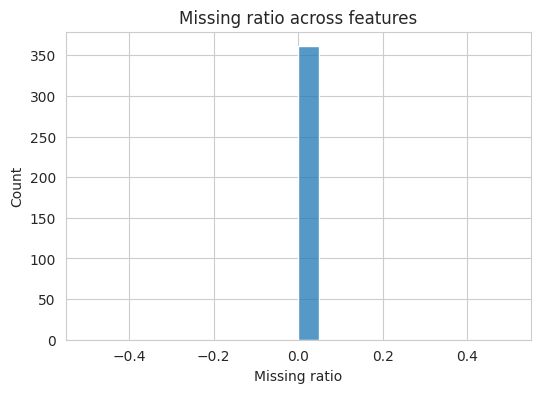

In [11]:
missingSummary = featuresDf.isna().mean().sort_values(ascending=False)
display(missingSummary.head(20))

plt.figure(figsize=(6,4))
sns.histplot(missingSummary.values, bins=20)
plt.title("Missing ratio across features")
plt.xlabel("Missing ratio")
plt.show()

# 4. Train Validation Test Split

Because the dataset is small, we use:
- a 20 percent hold out test set
- 5 fold cross validation on the training set
- threshold tuning based on out of fold predictions


### Step 12 - Audit Labels Before Cleaning

Inspect the target column before forcing it into a binary format.


In [12]:
print("Unique target before cleaning:")
print(featuresDf["target"].value_counts(dropna=False))
print("dtype:", featuresDf["target"].dtype)

Unique target before cleaning:
target
0    287
1     69
2      7
Name: count, dtype: int64
dtype: int64


### Step 13 - Clean the Target and Create the Hold Out Split

Clean the target labels and create a stratified train test split.


In [13]:
targetCol = "target"
dropCols = ["patient_id", "target"]

featuresDf[targetCol] = pd.to_numeric(featuresDf[targetCol], errors="coerce")

featuresDf = featuresDf[featuresDf[targetCol].isin([0, 1])].copy()
featuresDf[targetCol] = featuresDf[targetCol].astype(int)

print("Unique target after cleaning:")
print(featuresDf[targetCol].value_counts(dropna=False))

X = featuresDf.drop(columns=dropCols)
y = featuresDf[targetCol].astype(int).values

assert set(np.unique(y)).issubset({0, 1}), f"Target is still not binary: {np.unique(y)}"

xTrainDf, xTestDf, yTrain, yTest = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=randomState
)

print("Train shape:", xTrainDf.shape)
print("Test shape :", xTestDf.shape)
print("Train label distribution:", np.unique(yTrain, return_counts=True))
print("Test label distribution:", np.unique(yTest, return_counts=True))

Unique target after cleaning:
target
0    287
1     69
Name: count, dtype: int64
Train shape: (284, 359)
Test shape : (72, 359)
Train label distribution: (array([0, 1]), array([229,  55]))
Test label distribution: (array([0, 1]), array([58, 14]))


### Step 14 - XGBoost Cross Validation

Run median imputation, train cross validation folds, and collect out of fold predictions.


In [14]:
imputer = SimpleImputer(strategy="median")

xTrain = imputer.fit_transform(xTrainDf)
xTest = imputer.transform(xTestDf)

featureNames = xTrainDf.columns.tolist()

scalePosWeight = (len(yTrain) - yTrain.sum()) / max(yTrain.sum(), 1)
print("scale_pos_weight:", scalePosWeight)

cvSplitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=randomState)
oofPred = np.zeros(len(yTrain), dtype=float)

trainedModels = []

for fold, (trainIndex, validIndex) in enumerate(cvSplitter.split(xTrain, yTrain), 1):
    xTrainFold, xValidFold = xTrain[trainIndex], xTrain[validIndex]
    yTrainFold = yTrain[trainIndex].astype(int)
    yValidFold = yTrain[validIndex].astype(int)

    print(f"\nFold {fold}")
    print("y_tr distribution:", np.unique(yTrainFold, return_counts=True))
    print("y_va distribution:", np.unique(yValidFold, return_counts=True))

    model = XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.3,
        reg_lambda=1.5,
        min_child_weight=2,
        objective="binary:logistic",
        eval_metric="aucpr",
        random_state=randomState + fold,
        scale_pos_weight=scalePosWeight,
        tree_method="hist"
    )

    model.fit(xTrainFold, yTrainFold)

    validPred = model.predict_proba(xValidFold)[:, 1].astype(float)
    oofPred[validIndex] = validPred
    trainedModels.append(model)

    foldAuc = roc_auc_score(yValidFold, validPred)
    print(f"Fold {fold} AUC: {foldAuc:.4f}")

print("\nOOF AUC:", roc_auc_score(yTrain.astype(int), oofPred))

scale_pos_weight: 4.163636363636364

Fold 1
y_tr distribution: (array([0, 1]), array([183,  44]))
y_va distribution: (array([0, 1]), array([46, 11]))
Fold 1 AUC: 0.7945

Fold 2
y_tr distribution: (array([0, 1]), array([183,  44]))
y_va distribution: (array([0, 1]), array([46, 11]))
Fold 2 AUC: 0.7628

Fold 3
y_tr distribution: (array([0, 1]), array([183,  44]))
y_va distribution: (array([0, 1]), array([46, 11]))
Fold 3 AUC: 0.8202

Fold 4
y_tr distribution: (array([0, 1]), array([183,  44]))
y_va distribution: (array([0, 1]), array([46, 11]))
Fold 4 AUC: 0.8123

Fold 5
y_tr distribution: (array([0, 1]), array([184,  44]))
y_va distribution: (array([0, 1]), array([45, 11]))
Fold 5 AUC: 0.8182

OOF AUC: 0.7987296546248511


### Step 15 - Threshold Tuning

Search for the best classification threshold from the out of fold predictions using the precision recall curve and F1.


OOF PR-AUC      : 0.5473075441602199
Best threshold  : 0.18023563921451569
Best OOF F1     : 0.5294117647054005
OOF Precision   : 0.4444444444444444
OOF Recall      : 0.6545454545454545


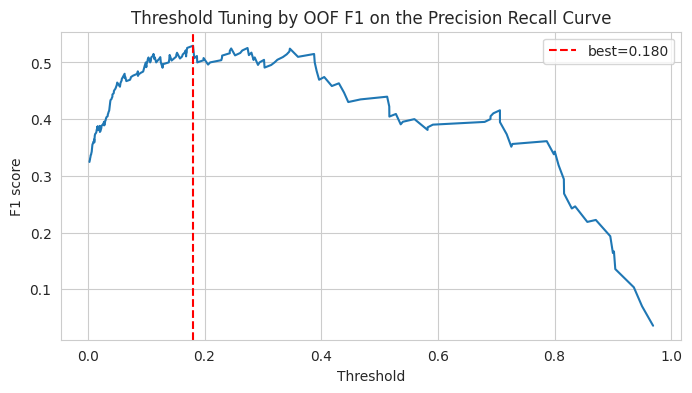

In [15]:
precisionValues, recallValues, thresholdValues = precision_recall_curve(yTrain, oofPred)
oofPrAuc = average_precision_score(yTrain, oofPred)

if len(thresholdValues) == 0:
    bestThreshold = 0.5
    bestF1 = f1_score(yTrain, (oofPred >= bestThreshold).astype(int))
    bestPrecision = precisionValues[0]
    bestRecall = recallValues[0]
    thresholdPlotX = np.array([bestThreshold])
    thresholdPlotY = np.array([bestF1])
else:
    f1Curve = (2 * precisionValues[:-1] * recallValues[:-1]) / (precisionValues[:-1] + recallValues[:-1] + 1e-12)
    bestIndex = np.argmax(f1Curve)
    bestThreshold = thresholdValues[bestIndex]
    bestF1 = f1Curve[bestIndex]
    bestPrecision = precisionValues[bestIndex]
    bestRecall = recallValues[bestIndex]
    thresholdPlotX = thresholdValues
    thresholdPlotY = f1Curve

print("OOF PR-AUC      :", oofPrAuc)
print("Best threshold  :", bestThreshold)
print("Best OOF F1     :", bestF1)
print("OOF Precision   :", bestPrecision)
print("OOF Recall      :", bestRecall)

plt.figure(figsize=(8,4))
plt.plot(thresholdPlotX, thresholdPlotY)
plt.axvline(bestThreshold, color="red", linestyle="--", label=f"best={bestThreshold:.3f}")
plt.title("Threshold Tuning by OOF F1 on the Precision Recall Curve")
plt.xlabel("Threshold")
plt.ylabel("F1 score")
plt.legend()
plt.show()

### Step 16 - Train the Final XGBoost Model

Train the final XGBoost model on the full training set.


In [16]:
finalModel = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.3,
    reg_lambda=1.5,
    min_child_weight=2,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=randomState,
    scale_pos_weight=scalePosWeight,
    tree_method="hist"
)

finalModel.fit(xTrain, yTrain)

testProba = finalModel.predict_proba(xTest)[:, 1]
testPred = (testProba >= bestThreshold).astype(int)

### Step 17 - Compute the Main Metrics

Evaluate ROC-AUC, PR-AUC, F1, balanced accuracy, sensitivity, specificity, and the classification report.


In [17]:
def specificityScore(yTrue, yPred):
    tn, fp, fn, tp = confusion_matrix(yTrue, yPred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

def sensitivityScore(yTrue, yPred):
    tn, fp, fn, tp = confusion_matrix(yTrue, yPred).ravel()
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

testPositiveRate = yTest.mean()
testAuc = roc_auc_score(yTest, testProba)
testPrAuc = average_precision_score(yTest, testProba)
testF1 = f1_score(yTest, testPred)
testAcc = accuracy_score(yTest, testPred)
testBalancedAcc = balanced_accuracy_score(yTest, testPred)
testSensitivity = sensitivityScore(yTest, testPred)
testSpecificity = specificityScore(yTest, testPred)

print(f"Chosen Threshold : {bestThreshold:.4f}")
print(f"Positive Rate    : {testPositiveRate:.4f}")
print(f"Test ROC-AUC     : {testAuc:.4f}")
print(f"Test PR-AUC      : {testPrAuc:.4f}")
print(f"Test F1          : {testF1:.4f}")
print(f"Test Accuracy    : {testAcc:.4f}")
print(f"Balanced Acc     : {testBalancedAcc:.4f}")
print(f"Test Sensitivity : {testSensitivity:.4f}")
print(f"Test Specificity : {testSpecificity:.4f}")

print("\nClassification Report")
print(classification_report(yTest, testPred, digits=4))

Chosen Threshold : 0.1802
Positive Rate    : 0.1944
Test ROC-AUC     : 0.8350
Test PR-AUC      : 0.5377
Test F1          : 0.5185
Test Accuracy    : 0.8194
Balanced Acc     : 0.6983
Test Sensitivity : 0.5000
Test Specificity : 0.8966

Classification Report
              precision    recall  f1-score   support

           0     0.8814    0.8966    0.8889        58
           1     0.5385    0.5000    0.5185        14

    accuracy                         0.8194        72
   macro avg     0.7099    0.6983    0.7037        72
weighted avg     0.8147    0.8194    0.8169        72



### Step 18 - Visualize the Evaluation

Show the confusion matrix, ROC curve, and precision recall curve for the imbalance aware model.


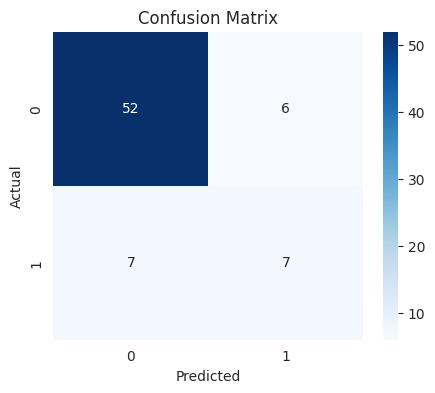

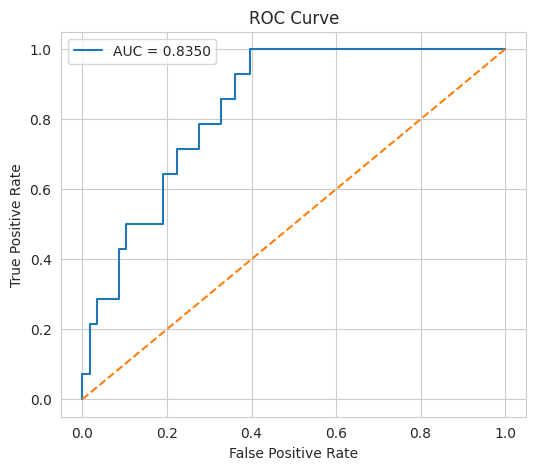

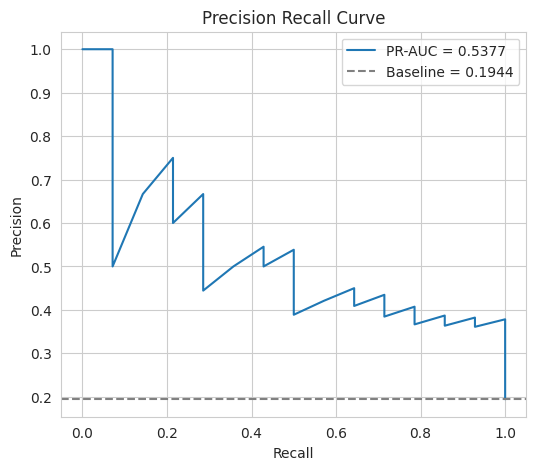

In [18]:
confusionMatrix = confusion_matrix(yTest, testPred)

plt.figure(figsize=(5,4))
sns.heatmap(confusionMatrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

falsePositiveRate, truePositiveRate, _ = roc_curve(yTest, testProba)

plt.figure(figsize=(6,5))
plt.plot(falsePositiveRate, truePositiveRate, label=f"AUC = {testAuc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

precisionCurve, recallCurve, _ = precision_recall_curve(yTest, testProba)

plt.figure(figsize=(6,5))
plt.plot(recallCurve, precisionCurve, label=f"PR-AUC = {testPrAuc:.4f}")
plt.axhline(testPositiveRate, color="gray", linestyle="--", label=f"Baseline = {testPositiveRate:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")
plt.legend()
plt.show()

### Step 19 - Feature Importance

Inspect the most influential features from the XGBoost model.


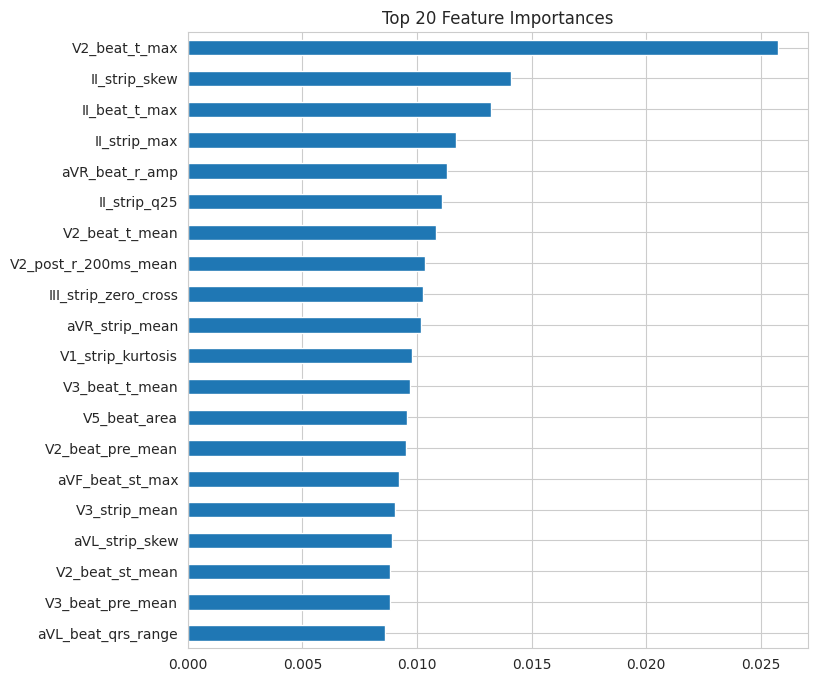

V2_beat_t_max           0.025781
II_strip_skew           0.014088
II_beat_t_max           0.013235
II_strip_max            0.011715
aVR_beat_r_amp          0.011291
II_strip_q25            0.011107
V2_beat_t_mean          0.010847
V2_post_r_200ms_mean    0.010340
III_strip_zero_cross    0.010266
aVR_strip_mean          0.010177
V1_strip_kurtosis       0.009772
V3_beat_t_mean          0.009705
V5_beat_area            0.009567
V2_beat_pre_mean        0.009532
aVF_beat_st_max         0.009210
V3_strip_mean           0.009047
aVL_strip_skew          0.008916
V2_beat_st_mean         0.008810
V3_beat_pre_mean        0.008802
aVL_beat_qrs_range      0.008618
dtype: float32

In [19]:
featureImportance = pd.Series(finalModel.feature_importances_, index=featureNames).sort_values(ascending=False)

topFeatures20 = featureImportance.head(20).sort_values()
plt.figure(figsize=(8,8))
topFeatures20.plot(kind="barh")
plt.title("Top 20 Feature Importances")
plt.show()

display(featureImportance.head(20))

### Step 20 - SHAP Analysis

Interpret feature contributions with a SHAP summary plot.


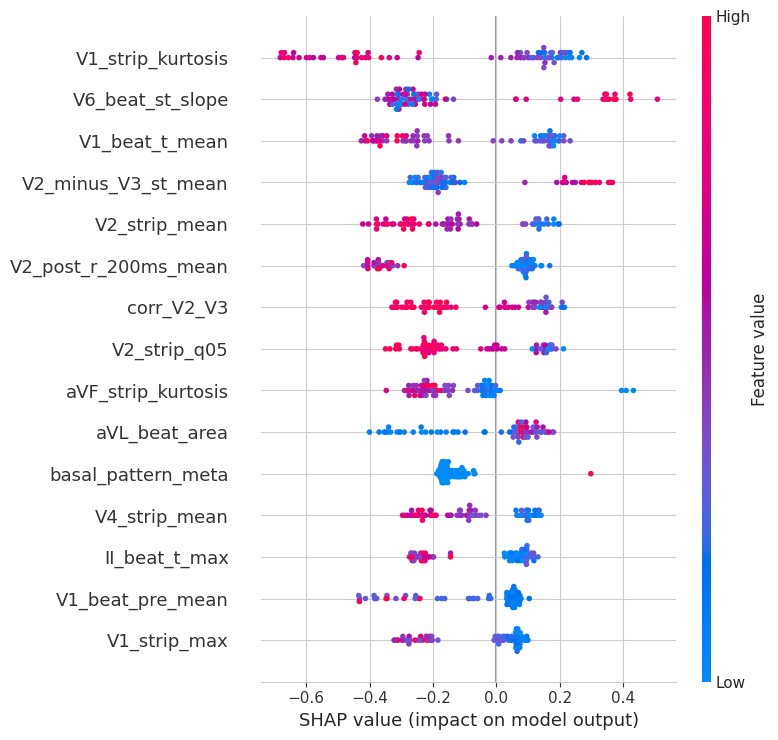

In [20]:
xTestDfImputed = pd.DataFrame(xTest, columns=featureNames)

shapExplainer = shap.TreeExplainer(finalModel)

if hasattr(shapExplainer, "shap_values"):
    shapValues = shapExplainer.shap_values(xTestDfImputed)
else:
    shapValues = shapExplainer(xTestDfImputed)

if isinstance(shapValues, list):
    shapValuesToPlot = shapValues[1] if len(shapValues) > 1 else shapValues[0]
elif hasattr(shapValues, "values"):
    shapValuesToPlot = shapValues.values
else:
    shapValuesToPlot = shapValues

if getattr(shapValuesToPlot, "ndim", 0) == 3:
    shapValuesToPlot = shapValuesToPlot[:, :, -1]

shap.summary_plot(shapValuesToPlot, xTestDfImputed, max_display=15)

### Step 21 - Aggregate Importance by Lead

Summarize the overall contribution of each ECG lead.


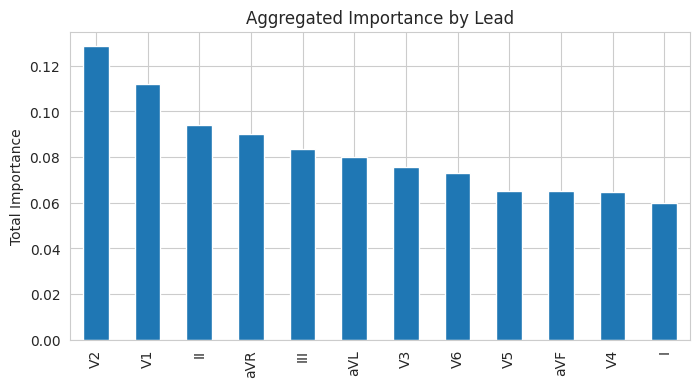

V2     0.128635
V1     0.112032
II     0.094114
aVR    0.090028
III    0.083608
aVL    0.079938
V3     0.075733
V6     0.072830
V5     0.065332
aVF    0.065010
V4     0.064712
I      0.060080
dtype: float32

In [21]:
leadScores = {}

for lead in standardLeads:
    leadScores[lead] = featureImportance[featureImportance.index.str.startswith(f"{lead}_")].sum()

leadScores = pd.Series(leadScores).sort_values(ascending=False)

plt.figure(figsize=(8,4))
leadScores.plot(kind="bar")
plt.title("Aggregated Importance by Lead")
plt.ylabel("Total Importance")
plt.show()

display(leadScores)

### Step 22 - Export Baseline Predictions

Save the baseline test predictions to a CSV file.


In [22]:
testResults = xTestDf.copy().reset_index(drop=True)
testResults["target"] = yTest
testResults["pred_proba"] = testProba
testResults["pred_label"] = testPred

mainPredictionFile = "Brugada Test Predictions.csv"
testResults.to_csv(mainPredictionFile, index=False)
print("Saved:", mainPredictionFile)

Saved: Brugada Test Predictions.csv


# Pitch Friendly Count Comparison

Add a class level evaluation so we can compare the actual count, predicted count, and correctly predicted count for each class.


### Step 23 - Baseline Count Comparison

Compare actual, predicted, and correctly predicted counts for XGBoost.


,Model,Class,Actual Count,Predicted Count,Correctly Predicted,Recall per Class,Precision on Predicted Class
0,XGBoost Features,Normal (0),58,59,52,0.896552,0.881356
1,XGBoost Features,Brugada (1),14,13,7,0.500000,0.538462
2,XGBoost Features,TOTAL,72,72,59,0.819444,NaN


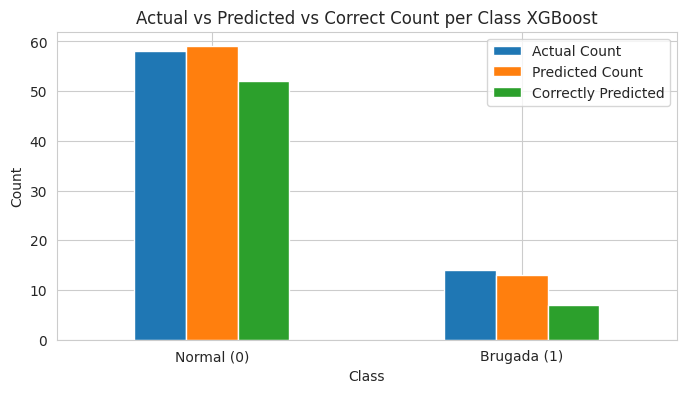

,y_true,y_pred,pred_proba,is_correct
0,0,1,0.201749,0
1,1,0,0.097069,0
2,0,0,0.005748,1
3,0,0,0.130453,1
4,0,0,0.038576,1
5,0,0,0.022015,1
6,0,0,0.011383,1
7,0,1,0.380884,0
8,0,0,0.010151,1
9,1,1,0.809320,1


Total correct predictions: 59
Total incorrect predictions: 13


In [23]:
def classCountReport(yTrue, yPred, modelName="Model"):
    yTrue = np.asarray(yTrue).astype(int)
    yPred = np.asarray(yPred).astype(int)
    featureRows = []
    for cls, className in [(0, "Normal"), (1, "Brugada")]:
        actualCount = int(np.sum(yTrue == cls))
        predictedCount = int(np.sum(yPred == cls))
        correctCount = int(np.sum((yTrue == cls) & (yPred == cls)))
        featureRows.append({
            "Model": modelName,
            "Class": f"{className} ({cls})",
            "Actual Count": actualCount,
            "Predicted Count": predictedCount,
            "Correctly Predicted": correctCount,
            "Recall per Class": correctCount / actualCount if actualCount > 0 else np.nan,
            "Precision on Predicted Class": correctCount / predictedCount if predictedCount > 0 else np.nan,
        })
    featureRows.append({
        "Model": modelName,
        "Class": "TOTAL",
        "Actual Count": len(yTrue),
        "Predicted Count": len(yPred),
        "Correctly Predicted": int(np.sum(yTrue == yPred)),
        "Recall per Class": float(np.mean(yTrue == yPred)),
        "Precision on Predicted Class": np.nan,
    })
    return pd.DataFrame(featureRows)

xgbCountReport = classCountReport(yTest, testPred, modelName="XGBoost Features")
display(xgbCountReport)

plotDf = xgbCountReport[xgbCountReport["Class"] != "TOTAL"].copy()
plotDf = plotDf.set_index("Class")[["Actual Count", "Predicted Count", "Correctly Predicted"]]
plotDf.plot(kind="bar", figsize=(8,4))
plt.title("Actual vs Predicted vs Correct Count per Class XGBoost")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

xgbDetail = pd.DataFrame({
    "y_true": yTest.astype(int),
    "y_pred": testPred.astype(int),
    "pred_proba": testProba.astype(float),
})
xgbDetail["is_correct"] = (xgbDetail["y_true"] == xgbDetail["y_pred"]).astype(int)
display(xgbDetail.head(20))
print("Total correct predictions:", int(xgbDetail["is_correct"].sum()))
print("Total incorrect predictions:", int(len(xgbDetail) - xgbDetail["is_correct"].sum()))

# Baseline Summary

This baseline pipeline already:
- reads ECG WFDB data automatically from Kaggle input
- preprocesses the signals and extracts the median beat
- builds explainable ECG morphology features
- trains an XGBoost classifier for Brugada versus Normal
- evaluates AUC, F1, sensitivity, and specificity
- adds interpretation through feature importance, SHAP, and class wise count evaluation

Recommendations from the last PDF page:
1. do not replace the baseline with deep learning too early
2. add a 1D CNN median beat model as a comparison model, not as the main replacement
3. if the CNN is weaker or unstable, keep XGBoost as the main model
4. show actual count, predicted count, and correctly predicted count per class during the pitch
5. focus the next experiments on leads V1 to V3 and make decisions based on evidence

Short pitch sentence:
We do not rely on overall accuracy alone. We also compare the actual class count, the predicted class count, and the correctly predicted class count so we can see whether the model truly detects Brugada cases.


# 6. Multi Model Benchmark

All models below use the same patient split so the comparison stays fair.

Models included in the benchmark:
- XGBoost Features
- Random Forest Features
- SVM RBF Features
- 1D CNN Median Beat
- ResNet 1D Median Beat
- CNN plus BiGRU Median Beat
- Transformer Encoder Median Beat
- Transfer Learning in domain denoising autoencoder to classifier

Notes:
- each model saves a test prediction CSV file
- transfer learning is built in domain with Brugada HUCA only, so it does not rely on external labeled datasets


### Step 24 - Extra Benchmark Dependencies

Import the additional libraries used for the classical benchmark and deep learning models.


In [24]:
import gc
import random
import re
import subprocess
import sys
import importlib.util
from pathlib import Path

if importlib.util.find_spec("tensorflow") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "tensorflow"])

import tensorflow as tf
from tensorflow.keras import callbacks, layers, models, optimizers
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_score
from IPython.display import Markdown, display

tf.get_logger().setLevel("ERROR")
predictionDir = Path("Model Predictions")
predictionDir.mkdir(exist_ok=True)


2026-03-19 14:35:29.665275: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773930929.871750      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773930929.933359      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773930930.448250      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773930930.448281      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773930930.448284      24 computation_placer.cc:177] computation placer alr

### Step 25 - Benchmark Utility Helpers

Prepare helper functions for seeds, threshold tuning, evaluation, and prediction export.


In [25]:
def setGlobalSeed(seed=randomState):
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

def formatFileLabel(text):
    words = re.sub(r"[^A-Za-z0-9]+", " ", str(text)).split()
    return " ".join(
        word if word.isupper() or any(ch.isupper() for ch in word[1:]) else word.capitalize()
        for word in words
    )

def buildCsvFileName(*parts):
    cleanParts = [formatFileLabel(part) for part in parts if str(part).strip()]
    return f"{' '.join(cleanParts)}.csv"

def tuneThreshold(yTrue, yProb, thresholdGrid=None):
    if thresholdGrid is None:
        thresholdGrid = np.linspace(0.15, 0.85, 71)
    yTrue = np.asarray(yTrue).astype(int)
    yProb = np.asarray(yProb).astype(float).ravel()
    bestThreshold = 0.5
    bestF1 = -1.0
    for threshold in thresholdGrid:
        pred = (yProb >= threshold).astype(int)
        score = f1_score(yTrue, pred, zero_division=0)
        if score > bestF1:
            bestF1 = float(score)
            bestThreshold = float(threshold)
    return bestThreshold, bestF1

def evaluateBinaryPredictions(modelName, patientIds, yTrue, yProb, threshold, splitName="test"):
    yTrue = np.asarray(yTrue).astype(int)
    yProb = np.asarray(yProb).astype(float).ravel()
    yPred = (yProb >= threshold).astype(int)

    predictionDf = pd.DataFrame({
        "patient_id": np.asarray(patientIds).astype(int),
        "target": yTrue,
        "pred_proba": yProb,
        "pred_label": yPred,
    })
    predictionDf["is_correct"] = (predictionDf["target"] == predictionDf["pred_label"]).astype(int)
    predictionPath = predictionDir / buildCsvFileName(modelName, splitName, "predictions")
    predictionDf.to_csv(predictionPath, index=False)

    countDf = classCountReport(yTrue, yPred, modelName=modelName)
    normalCorrect = int(countDf.loc[countDf["Class"] == "Normal (0)", "Correctly Predicted"].iloc[0])
    brugadaCorrect = int(countDf.loc[countDf["Class"] == "Brugada (1)", "Correctly Predicted"].iloc[0])

    modelMetrics = {
        "Model": modelName,
        "Threshold": float(threshold),
        "AUC": float(roc_auc_score(yTrue, yProb)),
        "F1": float(f1_score(yTrue, yPred, zero_division=0)),
        "Accuracy": float(accuracy_score(yTrue, yPred)),
        "Precision": float(precision_score(yTrue, yPred, zero_division=0)),
        "Sensitivity": float(sensitivityScore(yTrue, yPred)),
        "Specificity": float(specificityScore(yTrue, yPred)),
        "Correctly Predicted": int(np.sum(yTrue == yPred)),
        "Incorrectly Predicted": int(np.sum(yTrue != yPred)),
        "Normal Correct": normalCorrect,
        "Brugada Correct": brugadaCorrect,
        "Total Samples": int(len(yTrue)),
        "Prediction CSV": str(predictionPath),
    }
    return modelMetrics, predictionDf, countDf

def buildSequenceSample(patientId, focusLeads=None):
    X, leads, fs = loadEcgRecord(patientId)
    Xf = bandpassFilter(X, fs=fs, low=0.5, high=40.0, order=3)
    Xn = robustScale(Xf)
    median_beat, _ = extractMedianBeat(Xn, leads, fs)
    if focusLeads is not None:
        leadIndex = [leads.index(ld) for ld in focusLeads]
        median_beat = median_beat[:, leadIndex]
    return median_beat.astype(np.float32)

def makeClassWeightDict(y):
    y = np.asarray(y).astype(int).ravel()
    classes = np.unique(y)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    return {int(cls): float(weight) for cls, weight in zip(classes, weights)}

def prepareTargetsForBinaryModel(y, modelOutputShape=None):
    yArray = np.asarray(y).astype(np.float32).reshape(-1, 1)
    if modelOutputShape is not None and len(modelOutputShape) > 2:
        extraDims = tuple(int(dim) for dim in modelOutputShape[1:-1] if dim is not None)
        if extraDims:
            yArray = np.broadcast_to(
                yArray.reshape((-1,) + (1,) * len(extraDims) + (1,)),
                (len(yArray), *extraDims, 1),
            ).copy()
    return yArray

def makeSampleWeightArray(y, modelOutputShape=None):
    yFlat = np.asarray(y).astype(int).ravel()
    classWeight = makeClassWeightDict(yFlat)
    sampleWeight = np.array([classWeight[int(label)] for label in yFlat], dtype=np.float32)
    if modelOutputShape is not None and len(modelOutputShape) > 2:
        extraDims = tuple(int(dim) for dim in modelOutputShape[1:-1] if dim is not None)
        if extraDims:
            sampleWeight = np.broadcast_to(
                sampleWeight.reshape((-1,) + (1,) * len(extraDims)),
                (len(sampleWeight), *extraDims),
            ).copy()
    return sampleWeight, classWeight

def collapseBinaryPredictions(predictions):
    predArray = np.asarray(predictions).astype(np.float32)
    if predArray.ndim == 1:
        return predArray
    return predArray.reshape(predArray.shape[0], -1).mean(axis=1)

def makeTrainingCallbacks(monitor="val_auc", mode="max", patience=12):
    return [
        callbacks.EarlyStopping(
            monitor=monitor,
            mode=mode,
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=max(4, patience // 2),
            min_lr=1e-5,
            verbose=1,
        ),
    ]


### Step 26 - Shared Patient Split

Build one shared train validation test split for all benchmark models.


In [26]:
benchmarkDf = featuresDf.copy()
benchmarkDf["patient_id"] = pd.to_numeric(benchmarkDf["patient_id"], errors="coerce")
benchmarkDf["target"] = pd.to_numeric(benchmarkDf["target"], errors="coerce")
benchmarkDf = benchmarkDf.dropna(subset=["patient_id", "target"]).copy()
benchmarkDf = benchmarkDf[benchmarkDf["target"].isin([0, 1])].copy()
benchmarkDf["patient_id"] = benchmarkDf["patient_id"].astype(int)
benchmarkDf["target"] = benchmarkDf["target"].astype(int)
benchmarkDf = benchmarkDf.drop_duplicates(subset=["patient_id"]).reset_index(drop=True)

benchmarkPatientDf = benchmarkDf[["patient_id", "target"]].copy()

sequenceCache = {}
validRows = []
for row in tqdm(benchmarkPatientDf.itertuples(index=False), total=len(benchmarkPatientDf)):
    pid = int(row.patient_id)
    try:
        sequenceCache[pid] = buildSequenceSample(pid, focusLeads=standardLeads)
        validRows.append({"patient_id": pid, "target": int(row.target)})
    except Exception as exc:
        print(f"Skip patient_id={pid}: {exc}")

benchmarkPatientDf = pd.DataFrame(validRows)
benchmarkDf = benchmarkDf[benchmarkDf["patient_id"].isin(benchmarkPatientDf["patient_id"])].copy()
benchmarkDf = benchmarkDf.sort_values("patient_id").reset_index(drop=True)
benchmarkPatientDf = benchmarkPatientDf.sort_values("patient_id").reset_index(drop=True)

trainDf, testDf = train_test_split(
    benchmarkPatientDf,
    test_size=0.20,
    stratify=benchmarkPatientDf["target"],
    random_state=randomState,
)
trainDf, valDf = train_test_split(
    trainDf,
    test_size=0.20,
    stratify=trainDf["target"],
    random_state=randomState,
)

trainIds = trainDf["patient_id"].tolist()
valIds = valDf["patient_id"].tolist()
testIds = testDf["patient_id"].tolist()

labelByPatient = benchmarkPatientDf.set_index("patient_id")["target"].to_dict()
benchmarkFeatureCols = [columnName for columnName in benchmarkDf.columns if columnName not in ["patient_id", "target"]]
featureByPatient = benchmarkDf.set_index("patient_id")[benchmarkFeatureCols].sort_index()

def getTabularSplit(patientIds):
    xDf = featureByPatient.loc[patientIds].copy()
    y = np.array([labelByPatient[int(pid)] for pid in patientIds], dtype=int)
    return xDf, y

def getSequenceSplit(patientIds):
    X = np.stack([sequenceCache[int(pid)] for pid in patientIds]).astype(np.float32)
    y = np.array([labelByPatient[int(pid)] for pid in patientIds], dtype=int)
    return X, y

xTrainTabDf, yTrainTab = getTabularSplit(trainIds)
xValTabDf, yValTab = getTabularSplit(valIds)
xTestTabDf, yTestTab = getTabularSplit(testIds)

benchmarkImputer = SimpleImputer(strategy="median")
xTrainTab = benchmarkImputer.fit_transform(xTrainTabDf)
xValTab = benchmarkImputer.transform(xValTabDf)
xTestTab = benchmarkImputer.transform(xTestTabDf)

benchmarkScaler = StandardScaler()
xTrainTabScaled = benchmarkScaler.fit_transform(xTrainTab)
xValTabScaled = benchmarkScaler.transform(xValTab)
xTestTabScaled = benchmarkScaler.transform(xTestTab)

xTrainSeq, yTrainSeq = getSequenceSplit(trainIds)
xValSeq, yValSeq = getSequenceSplit(valIds)
xTestSeq, yTestSeq = getSequenceSplit(testIds)

print("Benchmark patient count:", len(benchmarkPatientDf))
print("Train Validation Test:", len(trainIds), len(valIds), len(testIds))
print("Train label distribution:", np.unique(yTrainTab, return_counts=True))
print("Validation label distribution:", np.unique(yValTab, return_counts=True))
print("Test label distribution:", np.unique(yTestTab, return_counts=True))
print("Tabular train shape:", xTrainTab.shape)
print("Sequence train shape:", xTrainSeq.shape)


  0%|          | 0/356 [00:00<?, ?it/s]

Benchmark patient count: 356
Train Validation Test: 227 57 72
Train label distribution: (array([0, 1]), array([183,  44]))
Validation label distribution: (array([0, 1]), array([46, 11]))
Test label distribution: (array([0, 1]), array([58, 14]))
Tabular train shape: (227, 359)
Sequence train shape: (227, 70, 12)


### Step 27 - Train the Classical Models

Train XGBoost, Random Forest, and SVM on the same tabular feature set.


In [27]:
benchmarkResults = []
benchmarkCountReports = []
benchmarkPredictionTables = {}
benchmarkHistories = {}

scalePosWeightBenchmark = (len(yTrainTab) - yTrainTab.sum()) / max(yTrainTab.sum(), 1)

classicalModels = {
    "XGBoost Features": XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.3,
        reg_lambda=1.5,
        min_child_weight=2,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=randomState,
        scale_pos_weight=scalePosWeightBenchmark,
        tree_method="hist",
    ),
    "Random Forest Features": RandomForestClassifier(
        n_estimators=600,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=randomState,
        n_jobs=-1,
    ),
    "SVM RBF Features": SVC(
        kernel="rbf",
        C=2.0,
        gamma="scale",
        probability=True,
        class_weight="balanced",
        random_state=randomState,
    ),
}

for modelName, model in classicalModels.items():
    print(f"\nTraining {modelName} ...")
    if "SVM" in modelName:
        xTrainInput, xValInput, xTestInput = xTrainTabScaled, xValTabScaled, xTestTabScaled
    else:
        xTrainInput, xValInput, xTestInput = xTrainTab, xValTab, xTestTab

    model.fit(xTrainInput, yTrainTab)
    valProba = model.predict_proba(xValInput)[:, 1].astype(float)
    bestThreshold, bestValF1 = tuneThreshold(yValTab, valProba)
    testProba = model.predict_proba(xTestInput)[:, 1].astype(float)

    modelMetrics, predictionDf, countDf = evaluateBinaryPredictions(
        modelName=modelName,
        patientIds=testIds,
        yTrue=yTestTab,
        yProb=testProba,
        threshold=bestThreshold,
    )
    modelMetrics["Validation F1"] = float(bestValF1)

    benchmarkResults.append(modelMetrics)
    benchmarkCountReports.append(countDf)
    benchmarkPredictionTables[modelName] = predictionDf

    print(
        f"{modelName} | AUC={modelMetrics['AUC']:.4f} | F1={modelMetrics['F1']:.4f} | "
        f"Correct={modelMetrics['Correctly Predicted']}/{modelMetrics['Total Samples']}"
    )
    print("Saved:", modelMetrics["Prediction CSV"])



Training XGBoost Features ...
XGBoost Features | AUC=0.8005 | F1=0.4348 | Correct=59/72
Saved: Model Predictions/XGBoost Features Test Predictions.csv

Training Random Forest Features ...
Random Forest Features | AUC=0.7081 | F1=0.3810 | Correct=59/72
Saved: Model Predictions/Random Forest Features Test Predictions.csv

Training SVM RBF Features ...
SVM RBF Features | AUC=0.7709 | F1=0.5333 | Correct=58/72
Saved: Model Predictions/SVM RBF Features Test Predictions.csv


## Deep Learning Models

All sequence models below use the same 12 lead median beat input so the architecture comparison remains consistent.


### Step 28 - Define the Deep Learning Architectures

Define 1D CNN, ResNet 1D, CNN plus BiGRU, and Transformer encoder models.


In [28]:
def residualBlock(x, filters, kernelSize=3, stride=1, dropoutRate=0.10):
    shortcut = x
    if stride != 1 or int(x.shape[-1]) != filters:
        shortcut = layers.Conv1D(filters, 1, strides=stride, padding="same")(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    y = layers.Conv1D(filters, kernelSize, strides=stride, padding="same")(x)
    y = layers.BatchNormalization()(y)
    y = layers.Activation("relu")(y)
    y = layers.Conv1D(filters, kernelSize, padding="same")(y)
    y = layers.BatchNormalization()(y)
    if dropoutRate > 0:
        y = layers.SpatialDropout1D(dropoutRate)(y)

    out = layers.Add()([shortcut, y])
    out = layers.Activation("relu")(out)
    return out

def buildCnn1d(inputShape, learningRate=1e-3):
    inp = layers.Input(shape=inputShape)
    x = layers.Conv1D(32, 7, padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(64, 5, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = models.Model(inp, out, name="cnn_1d")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learningRate),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")],
        jit_compile=False,
    )
    return model

def buildResnet1d(inputShape, learningRate=1e-3):
    inp = layers.Input(shape=inputShape)
    x = layers.Conv1D(32, 7, padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = residualBlock(x, 32, stride=1, dropoutRate=0.05)
    x = residualBlock(x, 64, stride=2, dropoutRate=0.10)
    x = residualBlock(x, 128, stride=2, dropoutRate=0.10)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = models.Model(inp, out, name="resnet_1d")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learningRate),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")],
        jit_compile=False,
    )
    return model

def buildCnnBigru(inputShape, learningRate=1e-3):
    inp = layers.Input(shape=inputShape)
    x = layers.Conv1D(32, 5, padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv1D(64, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Bidirectional(layers.GRU(64, return_sequences=True))(x)
    x = layers.Bidirectional(layers.GRU(32))(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = models.Model(inp, out, name="cnn_bigru")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learningRate),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")],
        jit_compile=False,
    )
    return model

def transformerBlock(x, numHeads=4, ffDim=128, dropoutRate=0.10):
    attn = layers.MultiHeadAttention(
        num_heads=numHeads,
        key_dim=max(8, int(x.shape[-1]) // numHeads),
        dropout=dropoutRate,
    )(x, x)
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    ff = layers.Dense(ffDim, activation="relu")(x)
    ff = layers.Dropout(dropoutRate)(ff)
    ff = layers.Dense(int(x.shape[-1]))(ff)

    x = layers.Add()([x, ff])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x

def buildTransformerModel(inputShape, learningRate=1e-3):
    inp = layers.Input(shape=inputShape)
    modelDim = 64
    x = layers.Dense(modelDim)(inp)
    posIndex = tf.range(start=0, limit=inputShape[0], delta=1)
    posEmbed = layers.Embedding(input_dim=inputShape[0], output_dim=modelDim)(posIndex)
    x = layers.Add()([x, posEmbed])
    x = transformerBlock(x, numHeads=4, ffDim=128, dropoutRate=0.10)
    x = transformerBlock(x, numHeads=4, ffDim=128, dropoutRate=0.10)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = models.Model(inp, out, name="transformer_1d")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learningRate),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")],
        jit_compile=False,
    )
    return model


### Step 29 - Transfer Learning and Training Helpers

Prepare the denoising autoencoder, the transfer learning classifier, and the training helpers.


In [29]:
def buildTransferEncoder(inputShape):
    inp = layers.Input(shape=inputShape)
    x = layers.Conv1D(32, 5, padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(2, padding="same")(x)
    x = residualBlock(x, 64, stride=1, dropoutRate=0.05)
    x = layers.MaxPooling1D(2, padding="same")(x)
    x = residualBlock(x, 128, stride=1, dropoutRate=0.10)
    return models.Model(inp, x, name="transfer_encoder")

def buildDenoisingAutoencoder(inputShape):
    encoder = buildTransferEncoder(inputShape)
    inp = layers.Input(shape=inputShape)
    x = layers.GaussianNoise(0.05)(inp)
    x = encoder(x)
    x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    x = layers.UpSampling1D(2)(x)
    x = layers.Conv1D(64, 3, padding="same", activation="relu")(x)
    x = layers.UpSampling1D(2)(x)
    x = layers.Conv1D(32, 3, padding="same", activation="relu")(x)
    x = layers.Conv1D(inputShape[-1], 1, padding="same")(x)

    currentLen = int(x.shape[1])
    targetLen = inputShape[0]
    if currentLen > targetLen:
        cropTotal = currentLen - targetLen
        cropLeft = cropTotal // 2
        cropRight = cropTotal - cropLeft
        x = layers.Cropping1D((cropLeft, cropRight))(x)
    elif currentLen < targetLen:
        padTotal = targetLen - currentLen
        padLeft = padTotal // 2
        padRight = padTotal - padLeft
        x = layers.ZeroPadding1D((padLeft, padRight))(x)

    autoencoder = models.Model(inp, x, name="denoising_autoencoder")
    autoencoder.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss="mse", jit_compile=False)
    return encoder, autoencoder

def buildTransferClassifier(encoder, inputShape, learningRate=3e-4):
    inp = layers.Input(shape=inputShape)
    x = encoder(inp)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.25)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = models.Model(inp, out, name="transfer_classifier")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learningRate),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")],
        jit_compile=False,
    )
    return model

def trainDeepClassifier(
    modelName,
    modelBuilder,
    xTrain,
    yTrain,
    xVal,
    yVal,
    xTest,
    yTest,
    testPatientIds,
    learningRate=1e-3,
    epochs=80,
    batchSize=16,
):
    tf.keras.backend.clear_session()
    gc.collect()
    setGlobalSeed(randomState)

    xTrain = np.asarray(xTrain).astype(np.float32)
    xVal = np.asarray(xVal).astype(np.float32)
    xTest = np.asarray(xTest).astype(np.float32)
    yTrainFlat = np.asarray(yTrain).astype(int).ravel()
    yValFlat = np.asarray(yVal).astype(int).ravel()
    yTestFlat = np.asarray(yTest).astype(int).ravel()

    model = modelBuilder(inputShape=xTrain.shape[1:], learningRate=learningRate)
    modelOutputShape = tuple(model.output_shape)
    yTrainFit = prepareTargetsForBinaryModel(yTrainFlat, modelOutputShape)
    yValFit = prepareTargetsForBinaryModel(yValFlat, modelOutputShape)
    trainSampleWeight, classWeight = makeSampleWeightArray(yTrainFlat, modelOutputShape)
    print("Output shape:", modelOutputShape)
    print("Class weight:", classWeight)
    history = model.fit(
        xTrain,
        yTrainFit,
        sample_weight=trainSampleWeight,
        validation_data=(xVal, yValFit),
        epochs=epochs,
        batch_size=batchSize,
        callbacks=makeTrainingCallbacks(monitor="val_auc", mode="max", patience=12),
        verbose=1,
    )

    valProba = collapseBinaryPredictions(model.predict(xVal, verbose=0))
    bestThreshold, bestValF1 = tuneThreshold(yValFlat, valProba)
    testProba = collapseBinaryPredictions(model.predict(xTest, verbose=0))

    modelMetrics, predictionDf, countDf = evaluateBinaryPredictions(
        modelName=modelName,
        patientIds=testPatientIds,
        yTrue=yTestFlat,
        yProb=testProba,
        threshold=bestThreshold,
    )
    modelMetrics["Validation F1"] = float(bestValF1)
    modelMetrics["Epochs Trained"] = int(len(history.history.get("loss", [])))

    historyDict = {key: [float(v) for v in values] for key, values in history.history.items()}

    del model
    tf.keras.backend.clear_session()
    gc.collect()
    return modelMetrics, predictionDf, countDf, historyDict

def trainTransferLearningModel(
    modelName,
    xTrain,
    yTrain,
    xVal,
    yVal,
    xTest,
    yTest,
    testPatientIds,
    pretrainEpochs=60,
    finetuneEpochs=80,
    batchSize=16,
):
    tf.keras.backend.clear_session()
    gc.collect()
    setGlobalSeed(randomState)

    xTrain = np.asarray(xTrain).astype(np.float32)
    xVal = np.asarray(xVal).astype(np.float32)
    xTest = np.asarray(xTest).astype(np.float32)
    yTrainFlat = np.asarray(yTrain).astype(int).ravel()
    yValFlat = np.asarray(yVal).astype(int).ravel()
    yTestFlat = np.asarray(yTest).astype(int).ravel()

    encoder, autoencoder = buildDenoisingAutoencoder(inputShape=xTrain.shape[1:])
    pretrainHistory = autoencoder.fit(
        xTrain,
        xTrain,
        validation_data=(xVal, xVal),
        epochs=pretrainEpochs,
        batch_size=batchSize,
        callbacks=makeTrainingCallbacks(monitor="val_loss", mode="min", patience=10),
        verbose=1,
    )

    classifier = buildTransferClassifier(
        encoder=encoder,
        inputShape=xTrain.shape[1:],
        learningRate=3e-4,
    )
    classifierOutputShape = tuple(classifier.output_shape)
    yTrainFit = prepareTargetsForBinaryModel(yTrainFlat, classifierOutputShape)
    yValFit = prepareTargetsForBinaryModel(yValFlat, classifierOutputShape)
    trainSampleWeight, classWeight = makeSampleWeightArray(yTrainFlat, classifierOutputShape)
    print("Output shape:", classifierOutputShape)
    print("Class weight:", classWeight)
    finetuneHistory = classifier.fit(
        xTrain,
        yTrainFit,
        sample_weight=trainSampleWeight,
        validation_data=(xVal, yValFit),
        epochs=finetuneEpochs,
        batch_size=batchSize,
        callbacks=makeTrainingCallbacks(monitor="val_auc", mode="max", patience=12),
        verbose=1,
    )

    valProba = collapseBinaryPredictions(classifier.predict(xVal, verbose=0))
    bestThreshold, bestValF1 = tuneThreshold(yValFlat, valProba)
    testProba = collapseBinaryPredictions(classifier.predict(xTest, verbose=0))

    modelMetrics, predictionDf, countDf = evaluateBinaryPredictions(
        modelName=modelName,
        patientIds=testPatientIds,
        yTrue=yTestFlat,
        yProb=testProba,
        threshold=bestThreshold,
    )
    modelMetrics["Validation F1"] = float(bestValF1)
    modelMetrics["Pretrain Epochs"] = int(len(pretrainHistory.history.get("loss", [])))
    modelMetrics["Epochs Trained"] = int(len(finetuneHistory.history.get("loss", [])))

    historyDict = {
        "pretrain": {key: [float(v) for v in values] for key, values in pretrainHistory.history.items()},
        "finetune": {key: [float(v) for v in values] for key, values in finetuneHistory.history.items()},
    }

    del autoencoder
    del classifier
    tf.keras.backend.clear_session()
    gc.collect()
    return modelMetrics, predictionDf, countDf, historyDict


### Step 30 - Train the Deep Learning Models

Train all deep learning models and save one test prediction CSV file per model.


In [30]:
deepModelBuilders = [
    ("1D CNN Median Beat", buildCnn1d, 1e-3),
    ("ResNet-1D Median Beat", buildResnet1d, 1e-3),
    ("CNN + BiGRU Median Beat", buildCnnBigru, 1e-3),
    ("Transformer Encoder Median Beat", buildTransformerModel, 8e-4),
]

deepTrainingFailures = []

for modelName, modelBuilder, learningRate in deepModelBuilders:
    print(f"\nTraining {modelName} ...")
    try:
        modelMetrics, predictionDf, countDf, historyDict = trainDeepClassifier(
            modelName=modelName,
            modelBuilder=modelBuilder,
            xTrain=xTrainSeq,
            yTrain=yTrainSeq,
            xVal=xValSeq,
            yVal=yValSeq,
            xTest=xTestSeq,
            yTest=yTestSeq,
            testPatientIds=testIds,
            learningRate=learningRate,
            epochs=80,
            batchSize=16,
        )
        benchmarkResults.append(modelMetrics)
        benchmarkCountReports.append(countDf)
        benchmarkPredictionTables[modelName] = predictionDf
        benchmarkHistories[modelName] = historyDict
        print(
            f"{modelName} | AUC={modelMetrics['AUC']:.4f} | F1={modelMetrics['F1']:.4f} | "
            f"Correct={modelMetrics['Correctly Predicted']}/{modelMetrics['Total Samples']}"
        )
        print("Saved:", modelMetrics["Prediction CSV"])
    except Exception as exc:
        tf.keras.backend.clear_session()
        gc.collect()
        deepTrainingFailures.append({"Model": modelName, "Stage": "Deep Classifier", "Error": str(exc)})
        print(f"Skipping {modelName} because of error: {exc}")

print("\nTraining Transfer Learning (in-domain) ...")
try:
    transferMetrics, transferPredDf, transferCountDf, transferHistory = trainTransferLearningModel(
        modelName="Transfer Learning Median Beat",
        xTrain=xTrainSeq,
        yTrain=yTrainSeq,
        xVal=xValSeq,
        yVal=yValSeq,
        xTest=xTestSeq,
        yTest=yTestSeq,
        testPatientIds=testIds,
        pretrainEpochs=60,
        finetuneEpochs=80,
        batchSize=16,
    )
    benchmarkResults.append(transferMetrics)
    benchmarkCountReports.append(transferCountDf)
    benchmarkPredictionTables["Transfer Learning Median Beat"] = transferPredDf
    benchmarkHistories["Transfer Learning Median Beat"] = transferHistory
    print(
        f"Transfer Learning Median Beat | AUC={transferMetrics['AUC']:.4f} | "
        f"F1={transferMetrics['F1']:.4f} | "
        f"Correct={transferMetrics['Correctly Predicted']}/{transferMetrics['Total Samples']}"
    )
    print("Saved:", transferMetrics["Prediction CSV"])
except Exception as exc:
    tf.keras.backend.clear_session()
    gc.collect()
    deepTrainingFailures.append({"Model": "Transfer Learning Median Beat", "Stage": "Transfer Learning", "Error": str(exc)})
    print(f"Skipping Transfer Learning Median Beat because of error: {exc}")

if deepTrainingFailures:
    deepTrainingFailureDf = pd.DataFrame(deepTrainingFailures)
    display(deepTrainingFailureDf)



Training 1D CNN Median Beat ...


I0000 00:00:1773930966.243370      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773930966.249365      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Output shape: (None, 1)
Class weight: {0: 0.6202185792349727, 1: 2.5795454545454546}
Epoch 1/80


I0000 00:00:1773930970.785392     101 cuda_dnn.cc:529] Loaded cuDNN version 91002


15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - auc: 0.5592 - loss: 0.6784 - val_auc: 0.7065 - val_loss: 0.4566 - learning_rate: 0.0010
Epoch 2/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - auc: 0.8427 - loss: 0.5163 - val_auc: 0.7045 - val_loss: 0.4571 - learning_rate: 0.0010
Epoch 3/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - auc: 0.8998 - loss: 0.4436 - val_auc: 0.7174 - val_loss: 0.4616 - learning_rate: 0.0010
Epoch 4/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - auc: 0.9214 - loss: 0.3786 - val_auc: 0.7332 - val_loss: 0.4589 - learning_rate: 0.0010
Epoch 5/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - auc: 0.9595 - loss: 0.3059 - val_auc: 0.7470 - val_loss: 0.4645 - learning_rate: 0.0010
Epoch 6/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - auc: 0.9745 - loss: 0.2600 - val_auc: 0.7698 - val_loss: 0.4595 - learning_rate: 0.0010
Epoch 7/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - auc: 0.9878 - loss: 0.1824 - val_auc: 0.7836 - val_loss: 0.4532 - learning_rate: 0.0010
Epoch 8/80
15/15 ━━━━━━━

,Model,Stage,Error
0,Transformer Encoder Median Beat,Deep Classifier,Graph execution error:\n\nDetected at node gra...


### Step 31 - Benchmark Leaderboard

Build the ranking table, save the benchmark summary CSV files, and create comparison plots.


,Model,Threshold,AUC,F1,Accuracy,Precision,Sensitivity,Specificity,Correctly Predicted,Incorrectly Predicted,Normal Correct,Brugada Correct,Total Samples,Prediction CSV,Validation F1,Epochs Trained,Pretrain Epochs
0,1D CNN Median Beat,0.29,0.732759,0.640000,0.875000,0.727273,0.571429,0.948276,63,9,55,8,72,Model Predictions/1D CNN Median Beat Test Pred...,0.608696,22.0,NaN
1,Transfer Learning Median Beat,0.71,0.714286,0.571429,0.875000,0.857143,0.428571,0.982759,63,9,57,6,72,Model Predictions/Transfer Learning Median Bea...,0.761905,44.0,60.0
2,XGBoost Features,0.31,0.800493,0.434783,0.819444,0.555556,0.357143,0.931034,59,13,54,5,72,Model Predictions/XGBoost Features Test Predic...,0.666667,NaN,NaN
3,ResNet-1D Median Beat,0.22,0.709360,0.580645,0.819444,0.529412,0.642857,0.862069,59,13,50,9,72,Model Predictions/ResNet 1D Median Beat Test P...,0.642857,27.0,NaN
4,Random Forest Features,0.35,0.708128,0.380952,0.819444,0.571429,0.285714,0.948276,59,13,55,4,72,Model Predictions/Random Forest Features Test ...,0.700000,NaN,NaN
5,SVM RBF Features,0.22,0.770936,0.533333,0.805556,0.500000,0.571429,0.862069,58,14,50,8,72,Model Predictions/SVM RBF Features Test Predic...,0.645161,NaN,NaN
6,CNN + BiGRU Median Beat,0.66,0.667488,0.413793,0.763889,0.400000,0.428571,0.844828,55,17,49,6,72,Model Predictions/CNN BiGRU Median Beat Test P...,0.592593,23.0,NaN


,Model,Class,Actual Count,Predicted Count,Correctly Predicted,Recall per Class,Precision on Predicted Class
0,XGBoost Features,Normal (0),58,63,54,0.931034,0.857143
1,XGBoost Features,Brugada (1),14,9,5,0.357143,0.555556
2,XGBoost Features,TOTAL,72,72,59,0.819444,NaN
3,Random Forest Features,Normal (0),58,65,55,0.948276,0.846154
4,Random Forest Features,Brugada (1),14,7,4,0.285714,0.571429
5,Random Forest Features,TOTAL,72,72,59,0.819444,NaN
6,SVM RBF Features,Normal (0),58,56,50,0.862069,0.892857
7,SVM RBF Features,Brugada (1),14,16,8,0.571429,0.500000
8,SVM RBF Features,TOTAL,72,72,58,0.805556,NaN
9,1D CNN Median Beat,Normal (0),58,61,55,0.948276,0.901639


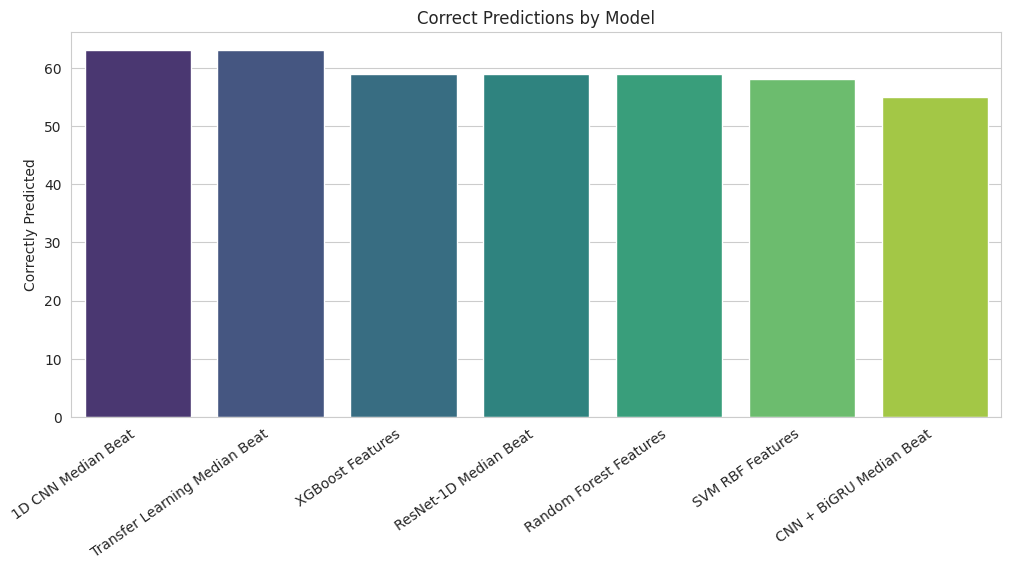

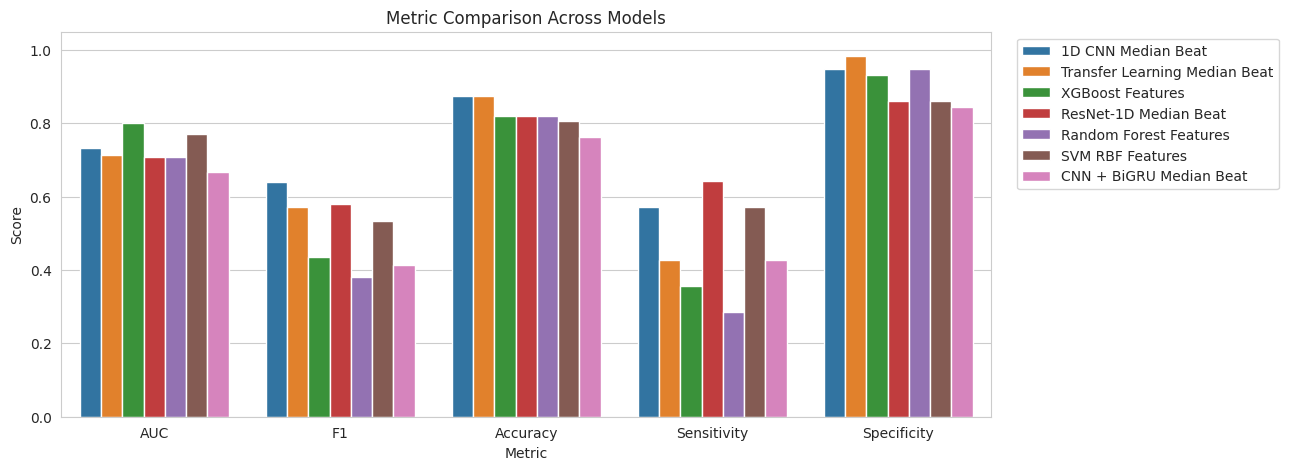

Saved summary: Model Benchmark Summary.csv
Saved count comparison: Model Count Comparison.csv
Best model: 1D CNN Median Beat


,patient_id,target,pred_proba,pred_label,is_correct
0,952177,0,0.133904,0,1
1,3080186,1,0.000066,0,0
2,1254062,0,0.008013,0,1
3,1294540,0,0.002895,0,1
4,1214441,0,0.001587,0,1
5,822756,0,0.021285,0,1
6,1286512,0,0.002227,0,1
7,1096625,0,0.022708,0,1
8,3062045,0,0.000563,0,1
9,898726,1,0.311758,1,1


,Model,Class,Actual Count,Predicted Count,Correctly Predicted,Recall per Class,Precision on Predicted Class
9,1D CNN Median Beat,Normal (0),58,61,55,0.948276,0.901639
10,1D CNN Median Beat,Brugada (1),14,11,8,0.571429,0.727273
11,1D CNN Median Beat,TOTAL,72,72,63,0.875000,NaN


In [31]:
benchmarkResultsDf = pd.DataFrame(benchmarkResults)
benchmarkResultsDf = benchmarkResultsDf.sort_values(
    by=["Correctly Predicted", "AUC", "F1", "Sensitivity", "Specificity"],
    ascending=[False, False, False, False, False],
).reset_index(drop=True)

benchmarkCountDf = pd.concat(benchmarkCountReports, axis=0).reset_index(drop=True)

benchmarkSummaryFile = buildCsvFileName("Model", "Benchmark", "Summary")
benchmarkCountFile = buildCsvFileName("Model", "Count", "Comparison")

benchmarkResultsDf.to_csv(benchmarkSummaryFile, index=False)
benchmarkCountDf.to_csv(benchmarkCountFile, index=False)

display(benchmarkResultsDf)
display(benchmarkCountDf)

plt.figure(figsize=(12, 5))
sns.barplot(data=benchmarkResultsDf, x="Model", y="Correctly Predicted", palette="viridis")
plt.title("Correct Predictions by Model")
plt.ylabel("Correctly Predicted")
plt.xlabel("")
plt.xticks(rotation=35, ha="right")
plt.show()

metricPlotDf = benchmarkResultsDf.melt(
    id_vars="Model",
    value_vars=["AUC", "F1", "Accuracy", "Sensitivity", "Specificity"],
    var_name="Metric",
    value_name="Score",
)
plt.figure(figsize=(12, 5))
sns.barplot(data=metricPlotDf, x="Metric", y="Score", hue="Model")
plt.title("Metric Comparison Across Models")
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

bestModelName = benchmarkResultsDf.loc[0, "Model"]
bestModelPredDf = benchmarkPredictionTables[bestModelName]
bestModelCountDf = benchmarkCountDf[benchmarkCountDf["Model"] == bestModelName].copy()

print("Saved summary:", benchmarkSummaryFile)
print("Saved count comparison:", benchmarkCountFile)
print("Best model:", bestModelName)
display(bestModelPredDf.head(20))
display(bestModelCountDf)


### Step 32 - Performance Analysis

Summarize the performance of each model and explain the trade offs that appear.


In [32]:
analysisLines = []
for row in benchmarkResultsDf.to_dict("records"):
    analysisLines.append(
        f"- {row['Model']}: {row['Correctly Predicted']}/{row['Total Samples']} correct predictions, "
        f"AUC={row['AUC']:.4f}, F1={row['F1']:.4f}, "
        f"Sensitivity={row['Sensitivity']:.4f}, Specificity={row['Specificity']:.4f}"
    )

print("Model performance summary:")
print("\n".join(analysisLines))

bestRow = benchmarkResultsDf.iloc[0]
secondRow = benchmarkResultsDf.iloc[1] if len(benchmarkResultsDf) > 1 else None

if bestRow["Model"] in {"XGBoost Features", "Random Forest Features", "SVM RBF Features"}:
    strategyNote = (
        "On this split, the feature based approach remains more stable than the sequence deep learning models."
    )
else:
    strategyNote = (
        "On this split, the sequence deep learning model captures median beat patterns better than the feature based baseline."
    )

if secondRow is not None:
    marginNote = (
        f"The best model is ahead by {int(bestRow['Correctly Predicted'] - secondRow['Correctly Predicted'])} "
        f"correct predictions compared with the second ranked model."
    )
else:
    marginNote = "Only one model was successfully evaluated."

print("\nShort analysis:")
print(strategyNote)
print(marginNote)
print("Pay attention to the sensitivity versus specificity trade off, especially for the smaller Brugada class.")


Model performance summary:
- 1D CNN Median Beat: 63/72 correct predictions, AUC=0.7328, F1=0.6400, Sensitivity=0.5714, Specificity=0.9483
- Transfer Learning Median Beat: 63/72 correct predictions, AUC=0.7143, F1=0.5714, Sensitivity=0.4286, Specificity=0.9828
- XGBoost Features: 59/72 correct predictions, AUC=0.8005, F1=0.4348, Sensitivity=0.3571, Specificity=0.9310
- ResNet-1D Median Beat: 59/72 correct predictions, AUC=0.7094, F1=0.5806, Sensitivity=0.6429, Specificity=0.8621
- Random Forest Features: 59/72 correct predictions, AUC=0.7081, F1=0.3810, Sensitivity=0.2857, Specificity=0.9483
- SVM RBF Features: 58/72 correct predictions, AUC=0.7709, F1=0.5333, Sensitivity=0.5714, Specificity=0.8621
- CNN + BiGRU Median Beat: 55/72 correct predictions, AUC=0.6675, F1=0.4138, Sensitivity=0.4286, Specificity=0.8448

Short analysis:
On this split, the sequence deep learning model captures median beat patterns better than the feature based baseline.
The best model is ahead by 0 correct predi

### Step 33 - Automatic Final Conclusion

Select the most optimal model and generate the final conclusion automatically.


In [33]:
bestRow = benchmarkResultsDf.iloc[0]
bestModelName = bestRow["Model"]
bestCountDf = benchmarkCountDf[benchmarkCountDf["Model"] == bestModelName].copy()

normalCorrect = int(bestCountDf.loc[bestCountDf["Class"] == "Normal (0)", "Correctly Predicted"].iloc[0])
brugadaCorrect = int(bestCountDf.loc[bestCountDf["Class"] == "Brugada (1)", "Correctly Predicted"].iloc[0])

if bestModelName in {"XGBoost Features", "Random Forest Features", "SVM RBF Features"}:
    interpretation = (
        "This means the explainable ECG morphology features still provide the best generalization on this patient split."
    )
else:
    interpretation = (
        "This means the sequence based median beat representation captures Brugada patterns more effectively on this patient split."
    )

videoPitchConclusionMd = f'''
# 3 Minute Video Pitch Conclusion

## Project Goal
This project aims to classify Brugada syndrome versus Normal ECG recordings from the HUCA dataset using machine learning and deep learning models.

## Best Model
The best model on the held out test split is **{bestModelName}**.

This model achieved **{int(bestRow["Correctly Predicted"])} correct predictions** out of **{int(bestRow["Total Samples"])}** test samples.

## Key Results
- AUC: {bestRow["AUC"]:.4f}
- F1 Score: {bestRow["F1"]:.4f}
- Accuracy: {bestRow["Accuracy"]:.4f}
- Sensitivity: {bestRow["Sensitivity"]:.4f}
- Specificity: {bestRow["Specificity"]:.4f}

## Class Level Performance
- Normal samples correctly identified: {normalCorrect}
- Brugada samples correctly identified: {brugadaCorrect}

## Interpretation
{interpretation}

Because Brugada cases are the minority class, model selection in this notebook does not rely on accuracy alone. It also considers discrimination and class level performance so the final model remains useful for the harder positive class.

## Closing Statement
Overall, this benchmark shows that **{bestModelName}** is the most reliable candidate on the current split and provides the strongest balance between detection performance and practical interpretability for Brugada screening.

## Output Files
- Best model test prediction file: {bestRow["Prediction CSV"]}
- Benchmark summary file: {benchmarkSummaryFile}
- Benchmark count comparison file: {benchmarkCountFile}
'''

videoPitchConclusionFile = Path("3 Minute Video Pitch Conclusion.md")
videoPitchConclusionFile.write_text(videoPitchConclusionMd.strip() + "\n", encoding="utf-8")
print("Saved:", videoPitchConclusionFile)


Saved: 3 Minute Video Pitch Conclusion.md
